# 第3章：Coding Attention Mechanisms

**目标：** 从零实现注意力机制——Transformer 的核心组件

```
简单权重注意力 → 可学习的自注意力(Q/K/V) → 因果掩码 → Multi-Head Attention
```

**前置回顾（第2章）：**
- 文本经过 Tokenization → Token Embedding + Positional Embedding → 输入向量
- 每个 token 得到一个 `d_model` 维的向量
- 现在的问题：每个 token 只知道自己，不知道上下文 → 注意力机制解决这个问题！

---

## 3.1 注意力机制的直觉理解

**核心问题：** 同一个词在不同语境中含义不同，如何让模型「根据上下文理解语义」？

**例子：**
- "The **bank** of the river was steep." → bank = 河岸
- "I went to the **bank** to withdraw money." → bank = 银行

**注意力的核心思想：**
- 对于每个 token，计算它与序列中**所有其他 token** 的相关性（注意力权重）
- 用这些权重对所有 token 的表示做加权平均，得到一个融合了上下文信息的新表示
- Token 是文本被拆分后的最小处理单元。它不是严格的"单词"或"字符"，而是模型处理语言时的基本"积木"。

```
输入:  [x₁, x₂, x₃, ..., xₙ]   每个 xᵢ 是独立的嵌入向量
                ↓ 注意力机制
输出:  [z₁, z₂, z₃, ..., zₙ]   每个 zᵢ 融合了全序列的上下文信息
```

> 💡 **关键洞察：** 注意力机制本质是一种**加权平均**——让模型自己学习「在当前位置应该关注哪些 token」。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)

# 准备一个简单的输入序列（6个token，每个token用3维向量表示）
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your     (x₁)
     [0.55, 0.87, 0.66],  # journey  (x₂)
     [0.57, 0.85, 0.64],  # starts   (x₃)
     [0.22, 0.58, 0.33],  # with     (x₄)
     [0.77, 0.25, 0.10],  # one      (x₅)
     [0.05, 0.80, 0.55]]  # step     (x₆)
)

print(f"输入序列 shape: {inputs.shape}")  # (6, 3)
print(f"→ {inputs.shape[0]} 个 token，每个 {inputs.shape[1]} 维")

输入序列 shape: torch.Size([6, 3])
→ 6 个 token，每个 3 维


---
## 3.2 简化的自注意力（无可学习参数）

我们先实现最简单的版本：用**点积**计算 token 之间的相似度，然后做加权平均。

**步骤：**
1. 计算 query token 与所有 token 的点积（相似度分数）
2. 用 softmax 归一化为概率（注意力权重）
3. 用权重对所有 token 做加权平均 → 得到上下文向量

In [2]:
# Step 1: 以 x₂ ("journey") 为例，计算它和所有 token 的点积
query = inputs[1]  # x₂

attn_scores = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores[i] = torch.dot(query, x_i)

print(f"注意力分数 (原始点积): {attn_scores}")
print(f"→ x₂ 与自己的点积最大: {attn_scores[1]:.4f}")
print(f"→ x₂ 与 x₃ 的点积也很大: {attn_scores[2]:.4f} (因为向量很相似)")

注意力分数 (原始点积): tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
→ x₂ 与自己的点积最大: 1.4950
→ x₂ 与 x₃ 的点积也很大: 1.4754 (因为向量很相似)


In [3]:
# Step 2: softmax 归一化
attn_weights = F.softmax(attn_scores, dim=0)

print(f"注意力权重 (softmax后): {attn_weights}")
print(f"权重之和: {attn_weights.sum():.4f}")  # 应该 = 1.0
print(f"\n→ x₂ 最关注自己 ({attn_weights[1]:.4f}) 和 x₃ ({attn_weights[2]:.4f})")

注意力权重 (softmax后): tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
权重之和: 1.0000

→ x₂ 最关注自己 (0.2379) 和 x₃ (0.2333)


In [4]:
# Step 3: 加权平均 → 上下文向量
context_vec = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vec += attn_weights[i] * x_i

print(f"x₂ 的上下文向量: {context_vec}")
print(f"原始 x₂:         {query}")
print(f"\n→ 上下文向量融合了其他 token 的信息，与原始 x₂ 不同")

x₂ 的上下文向量: tensor([0.4419, 0.6515, 0.5683])
原始 x₂:         tensor([0.5500, 0.8700, 0.6600])

→ 上下文向量融合了其他 token 的信息，与原始 x₂ 不同


In [5]:
# 向量化：一次性计算所有 token 的注意力（矩阵乘法）
# attn_scores[i][j] = dot(inputs[i], inputs[j])
attn_scores_all = inputs @ inputs.T
print(f"注意力分数矩阵 shape: {attn_scores_all.shape}")
print(f"\n注意力分数矩阵:\n{attn_scores_all}")

# softmax 对每行归一化
attn_weights_all = F.softmax(attn_scores_all, dim=-1)
print(f"\n注意力权重矩阵:\n{attn_weights_all}")
print(f"\n每行之和: {attn_weights_all.sum(dim=-1)}")

# 一步得到所有上下文向量
all_context_vecs = attn_weights_all @ inputs
print(f"\n所有上下文向量 shape: {all_context_vecs.shape}")
print(f"x₂ 的上下文向量 (矩阵版): {all_context_vecs[1]}")
print(f"x₂ 的上下文向量 (循环版): {context_vec}")
print(f"→ 两者一致！")

注意力分数矩阵 shape: torch.Size([6, 6])

注意力分数矩阵:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

注意力权重矩阵:
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

每行之和: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

所有上下文向量 shape: torch.Size([6, 3])
x₂ 的上下文向量 (矩阵版): tensor([0.4419, 0.6515, 0.5683])
x₂ 的上下文向量 (循环版): tensor([0.4419, 0.6515, 0.5683])
→ 两者一致！


### ✏️ 练习
1. 为什么用 softmax 而不是简单的除以总和来归一化？两者有什么区别？
2. 如果把 `dim=-1` 改成 `dim=0`，softmax 的效果会怎样？这两种归一化方式分别对应什么含义？
3. 观察注意力权重矩阵，为什么对角线上的值往往最大？

In [9]:
# 在这里做实验
1.# 向量化：一次性计算所有 token 的注意力（矩阵乘法）
# attn_scores[i][j] = dot(inputs[i], inputs[j])
attn_scores_all = inputs @ inputs.T
print(f"注意力分数矩阵 shape: {attn_scores_all.shape}")
# print(f"\n注意力分数矩阵:\n{attn_scores_all}")

# 除以总和对每行归一化
row_sums = attn_scores_all.sum(dim=-1, keepdim=True)
attn_weights_all = attn_scores_all / row_sums
print(f"\n注意力权重矩阵:\n{attn_weights_all}")
print(f"\n每行之和: {attn_weights_all.sum(dim=-1)}")

# 一步得到所有上下文向量
all_context_vecs = attn_weights_all @ inputs
print(f"\n所有上下文向量 shape: {all_context_vecs.shape}")
print(f"x₂ 的上下文向量 (矩阵版): {all_context_vecs[1]}")
print(f"x₂ 的上下文向量 (循环版): {context_vec}")
print(f"→ 两者一致！")

注意力分数矩阵 shape: torch.Size([6, 6])

注意力权重矩阵:
tensor([[0.2241, 0.2140, 0.2113, 0.1066, 0.1026, 0.1415],
        [0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656],
        [0.1454, 0.2277, 0.2248, 0.1280, 0.1104, 0.1637],
        [0.1304, 0.2313, 0.2275, 0.1354, 0.0953, 0.1801],
        [0.1436, 0.2219, 0.2245, 0.1090, 0.2088, 0.0921],
        [0.1350, 0.2325, 0.2269, 0.1405, 0.0628, 0.2022]])

每行之和: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

所有上下文向量 shape: torch.Size([6, 3])
x₂ 的上下文向量 (矩阵版): tensor([0.4355, 0.6451, 0.5680])
x₂ 的上下文向量 (循环版): tensor([0.4419, 0.6515, 0.5683])
→ 两者一致！


In [11]:
print("【关键问题分析】")

# 1. 负分数问题
print("\n1️⃣ 负分数导致权重为负（破坏注意力语义）")
neg_mask = attn_scores_all < 0
print(f"负分数位置:\n{neg_mask}")
print(f"对应的'权重'值:\n{attn_weights_all[neg_mask][:10]}")

# 2. 权重范围失控
print(f"\n2️⃣ 权重范围失控: [{attn_weights_all.min():.4f}, {attn_weights_all.max():.4f}]")
print("   Softmax 版范围: [0, 1] 且和为1")

# 3. 对比：如果分数差异大
print("\n3️⃣ 模拟极端情况：某token分数远高于其他")
extreme_scores = torch.tensor([[1.0, 0.1, 0.1, 0.1]])
print(f"极端分数: {extreme_scores}")
print(f"Softmax 结果: {F.softmax(extreme_scores, dim=-1)}")  # 突出重要token
print(f"除总和结果: {extreme_scores / extreme_scores.sum()}")  # 仍给低分token大量权重

【关键问题分析】

1️⃣ 负分数导致权重为负（破坏注意力语义）
负分数位置:
tensor([[False,  True, False,  True,  True, False],
        [ True, False,  True, False,  True, False],
        [False,  True, False, False,  True, False],
        [ True, False, False, False,  True,  True],
        [ True,  True,  True,  True, False,  True],
        [False, False, False,  True,  True, False]])
对应的'权重'值:
tensor([0.2140, 0.1066, 0.1026, 0.1455, 0.2249, 0.1077, 0.2277, 0.1104, 0.1304,
        0.0953])

2️⃣ 权重范围失控: [0.0628, 0.2325]
   Softmax 版范围: [0, 1] 且和为1

3️⃣ 模拟极端情况：某token分数远高于其他
极端分数: tensor([[1.0000, 0.1000, 0.1000, 0.1000]])
Softmax 结果: tensor([[0.4505, 0.1832, 0.1832, 0.1832]])
除总和结果: tensor([[0.7692, 0.0769, 0.0769, 0.0769]])


In [ ]:
# 向量化：一次性计算所有 token 的注意力（矩阵乘法）
# attn_scores[i][j] = dot(inputs[i], inputs[j])
attn_scores_all = inputs @ inputs.T
print(f"注意力分数矩阵 shape: {attn_scores_all.shape}")
print(f"\n注意力分数矩阵:\n{attn_scores_all}")

# softmax 对每行归一化
attn_weights_all = F.softmax(attn_scores_all, dim=0)
print(f"\n注意力权重矩阵:\n{attn_weights_all}")
print(f"\n每行之和: {attn_weights_all.sum(dim=0)}")

# 一步得到所有上下文向量
all_context_vecs = attn_weights_all @ inputs
print(f"\n所有上下文向量 shape: {all_context_vecs.shape}")
print(f"x₂ 的上下文向量 (矩阵版): {all_context_vecs[1]}")
print(f"x₂ 的上下文向量 (循环版): {context_vec}")
print(f"→ 两者不一致！")

注意力分数矩阵 shape: torch.Size([6, 6])

注意力分数矩阵:
tensor([[ 6.1724, -0.8169,  3.8656, -1.0790, -0.2591,  1.3930],
        [-0.8169,  1.9308, -0.5384,  0.6746, -0.4048,  0.1861],
        [ 3.8656, -0.5384,  3.5924,  0.9511, -0.2048,  0.0272],
        [-1.0790,  0.6746,  0.9511,  2.6256, -0.1513, -1.3076],
        [-0.2591, -0.4048, -0.2048, -0.1513,  0.1187, -0.1125],
        [ 1.3930,  0.1861,  0.0272, -1.3076, -0.1125,  0.9919]])

注意力权重矩阵:
tensor([[8.9991e-01, 3.7585e-02, 5.3591e-01, 1.7137e-02, 1.5036e-01, 3.9795e-01],
        [8.2946e-04, 5.8653e-01, 6.5533e-03, 9.8980e-02, 1.2997e-01, 1.1903e-01],
        [8.9613e-02, 4.9654e-02, 4.0779e-01, 1.3050e-01, 1.5874e-01, 1.0155e-01],
        [6.3817e-04, 1.6701e-01, 2.9062e-02, 6.9641e-01, 1.6747e-01, 2.6726e-02],
        [1.4489e-03, 5.6752e-02, 9.1478e-03, 4.3338e-02, 2.1937e-01, 8.8300e-02],
        [7.5604e-03, 1.0247e-01, 1.1537e-02, 1.3635e-02, 1.7408e-01, 2.6644e-01]])

每行之和: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

所有上

---
## 3.3 带可学习参数的自注意力 (Q/K/V) ⭐⭐

上面的简化版有一个根本问题：注意力权重完全由输入的相似度决定，**模型无法学习**。

**解决方案：** 引入三个可学习的投影矩阵 $W_q$, $W_k$, $W_v$：

$$
q_i = x_i W_q, \quad k_i = x_i W_k, \quad v_i = x_i W_v
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

**三种向量的直觉：**
- **Query (查询)**: 「我在找什么信息？」
- **Key (键)**: 「我能提供什么信息？」
- **Value (值)**: 「我实际包含的信息是什么？」

> 💡 **为什么除以 $\sqrt{d_k}$？** 防止点积随着维度增大而变得过大，导致 softmax 输出接近 one-hot（梯度消失）。

In [13]:
# 先用手动矩阵实现，理解原理

x_2 = inputs[1]  # 以 x₂ 为例
d_in = inputs.shape[1]   # 输入维度 = 3
d_out = 2                # 输出维度 = 2 (为了演示，Q/K/V 投影到更低维度)

# 三个可学习的权重矩阵
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

# 计算 x₂ 的 query
query_2 = x_2 @ W_query
print(f"x₂ 的 Query: {query_2}  (shape: {query_2.shape})")

# 计算所有 token 的 key 和 value
keys = inputs @ W_key
values = inputs @ W_value
print(f"Keys shape:   {keys.shape}")   # (6, 2)
print(f"Values shape: {values.shape}")  # (6, 2)

x₂ 的 Query: tensor([0.0191, 0.6394])  (shape: torch.Size([2]))
Keys shape:   torch.Size([6, 2])
Values shape: torch.Size([6, 2])


In [14]:
# 计算 x₂ 对所有 token 的注意力分数
attn_scores_2 = query_2 @ keys.T  # (2,) @ (2, 6) → (6,)
print(f"注意力分数: {attn_scores_2}")

# Scaled dot-product: 除以 sqrt(d_k)
d_k = keys.shape[-1]
attn_weights_2 = F.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(f"注意力权重 (scaled): {attn_weights_2}")

# 加权平均得到上下文向量
context_vec_2 = attn_weights_2 @ values
print(f"\nx₂ 的上下文向量: {context_vec_2}")
print(f"→ 维度从 {d_in} 变为 {d_out}，因为 V 的投影维度是 {d_out}")

注意力分数: tensor([ 0.6059,  0.1554,  0.9997,  0.8334, -0.1083, -0.2626])
注意力权重 (scaled): tensor([0.1863, 0.1355, 0.2461, 0.2188, 0.1124, 0.1008])

x₂ 的上下文向量: tensor([0.3030, 0.6846])
→ 维度从 3 变为 2，因为 V 的投影维度是 2


In [15]:
# 封装为 nn.Module
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        queries = x @ self.W_query
        keys    = x @ self.W_key
        values  = x @ self.W_value

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in=3, d_out=2)
output = sa_v1(inputs)
print(f"自注意力输出 shape: {output.shape}")
print(f"输出:\n{output}")

自注意力输出 shape: torch.Size([6, 2])
输出:
tensor([[0.4256, 0.9208],
        [0.3030, 0.6846],
        [0.4413, 0.9490],
        [0.3713, 0.8173],
        [0.1712, 0.4149],
        [0.2072, 0.4929]], grad_fn=<MmBackward0>)


In [16]:
# 改进版：使用 nn.Linear 代替手动 Parameter（更规范，支持 bias 选项）
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in=3, d_out=2)
output_v2 = sa_v2(inputs)
print(f"SelfAttention_v2 输出:\n{output_v2}")

SelfAttention_v2 输出:
tensor([[-0.0261,  0.0962],
        [ 0.0325,  0.1975],
        [-0.0152,  0.1091],
        [ 0.0179,  0.1680],
        [ 0.0112,  0.1753],
        [ 0.0100,  0.1716]], grad_fn=<MmBackward0>)


### 🤔 思考：`nn.Parameter` vs `nn.Linear`

| 方式 | 本质 | 区别 |
|------|------|------|
| `nn.Parameter(torch.rand(d_in, d_out))` | 手动创建可学习矩阵 | `x @ W`，转置是手动的 |
| `nn.Linear(d_in, d_out, bias=False)` | 自动管理的线性层 | 内部做 `x @ W.T + bias`，权重初始化更合理 |

在实际实现中，推荐使用 `nn.Linear`，因为它有更好的权重初始化策略。

### ✏️ 练习
1. 在 `SelfAttention_v1` 中，如果去掉 `/ keys.shape[-1]**0.5`（不做 scaling），注意力权重会有什么变化？为什么？
2. `SelfAttention_v2` 用了 `nn.Linear`，它的权重矩阵 shape 和 `v1` 有什么不同？（提示：`nn.Linear` 内部存储的是转置后的矩阵）
3. 如果 `d_out > d_in` 会怎样？这在实际中有意义吗？

In [17]:
# 在这里做实验
#1
# 封装为 nn.Module
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        queries = x @ self.W_query
        keys    = x @ self.W_key
        values  = x @ self.W_value

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in=3, d_out=2)
output = sa_v1(inputs)
print(f"自注意力输出 shape: {output.shape}")
print(f"输出:\n{output}")

自注意力输出 shape: torch.Size([6, 2])
输出:
tensor([[0.4713, 1.0018],
        [0.3356, 0.7485],
        [0.4850, 1.0255],
        [0.4176, 0.9048],
        [0.1531, 0.3758],
        [0.2034, 0.4858]], grad_fn=<MmBackward0>)


---
## 3.4 因果注意力 (Causal Attention) ⭐⭐⭐

**问题：** 上面的自注意力是「双向」的——每个 token 能看到全部序列。但 GPT 是自回归模型，预测下一个 token 时**不能看到未来**！

**解决方案：因果掩码（Causal Mask）**
- 把注意力矩阵的**上三角**设为 $-\infty$
- softmax 后这些位置变成 0
- 效果：token $i$ 只能关注 $\leq i$ 位置的 token

```
无掩码:          有掩码:
✓ ✓ ✓ ✓         ✓ ✗ ✗ ✗
✓ ✓ ✓ ✓   →     ✓ ✓ ✗ ✗
✓ ✓ ✓ ✓         ✓ ✓ ✓ ✗
✓ ✓ ✓ ✓         ✓ ✓ ✓ ✓
```

In [18]:
# 演示因果掩码的实现

# Step 1: 计算正常的注意力分数
queries = sa_v2.W_query(inputs)
keys    = sa_v2.W_key(inputs)
values  = sa_v2.W_value(inputs)

attn_scores = queries @ keys.T
print(f"原始注意力分数:\n{attn_scores}")

原始注意力分数:
tensor([[-0.2541,  1.0199, -0.0444,  0.5126, -0.2323,  0.0505],
        [ 0.0109,  0.2507, -0.1687, -0.1682, -0.0540,  0.1769],
        [-0.2473,  1.1417, -0.1295,  0.4251, -0.2585,  0.1396],
        [-0.0858,  0.6442, -0.1886,  0.0243, -0.1436,  0.1993],
        [ 0.0198, -0.1570,  0.0483, -0.0016,  0.0349, -0.0510],
        [ 0.0015, -0.0561,  0.0292,  0.0217,  0.0123, -0.0307]],
       grad_fn=<MmBackward0>)


In [19]:
# Step 2: 创建因果掩码（上三角为 True）
seq_len = inputs.shape[0]
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
print(f"因果掩码 (True = 被遮挡):\n{mask.int()}")

因果掩码 (True = 被遮挡):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)


In [20]:
# Step 3: 将被遮挡的位置设为 -inf
attn_scores_masked = attn_scores.masked_fill(mask, -torch.inf)
print(f"掩码后的注意力分数:\n{attn_scores_masked}")

掩码后的注意力分数:
tensor([[-0.2541,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.0109,  0.2507,    -inf,    -inf,    -inf,    -inf],
        [-0.2473,  1.1417, -0.1295,    -inf,    -inf,    -inf],
        [-0.0858,  0.6442, -0.1886,  0.0243,    -inf,    -inf],
        [ 0.0198, -0.1570,  0.0483, -0.0016,  0.0349,    -inf],
        [ 0.0015, -0.0561,  0.0292,  0.0217,  0.0123, -0.0307]],
       grad_fn=<MaskedFillBackward0>)


In [21]:
# Step 4: softmax → 被遮挡的位置变成 0
attn_weights_masked = F.softmax(attn_scores_masked / keys.shape[-1]**0.5, dim=-1)
print(f"因果注意力权重:\n{attn_weights_masked}")
print(f"\n→ 每行只有前 i+1 个位置有非零权重！")
print(f"→ 第1个 token 只能关注自己")
print(f"→ 最后一个 token 能关注所有 token")

因果注意力权重:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4577, 0.5423, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2102, 0.5613, 0.2285, 0.0000, 0.0000, 0.0000],
        [0.2134, 0.3575, 0.1984, 0.2307, 0.0000, 0.0000],
        [0.2041, 0.1802, 0.2083, 0.2011, 0.2063, 0.0000],
        [0.1672, 0.1606, 0.1706, 0.1697, 0.1685, 0.1635]],
       grad_fn=<SoftmaxBackward0>)

→ 每行只有前 i+1 个位置有非零权重！
→ 第1个 token 只能关注自己
→ 最后一个 token 能关注所有 token


findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\quxin\AppData\Local\Temp\ipykernel_30476\3803227651.py:25: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\quxin\AppData\Local\Temp\ipykernel_30476\3803227651.py:25: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\quxin\AppData\Local\Temp\ipykernel_30476\3803227651.py:25

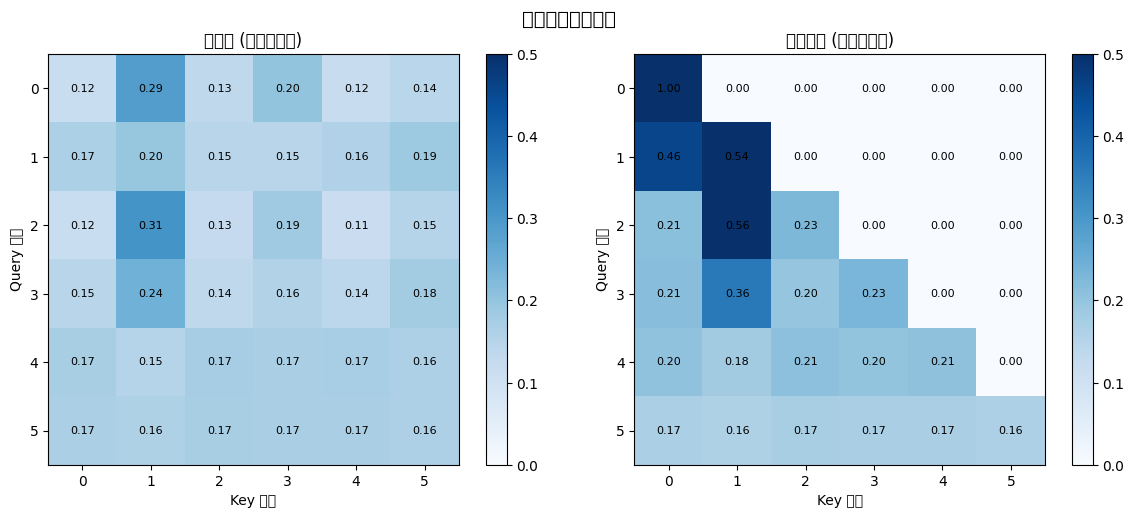

In [22]:
# 可视化：对比有/无因果掩码
attn_weights_no_mask = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(attn_weights_no_mask.detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[0].set_title('无掩码 (双向注意力)')
axes[0].set_xlabel('Key 位置')
axes[0].set_ylabel('Query 位置')
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, f'{attn_weights_no_mask[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(attn_weights_masked.detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[1].set_title('因果掩码 (单向注意力)')
axes[1].set_xlabel('Key 位置')
axes[1].set_ylabel('Query 位置')
for i in range(seq_len):
    for j in range(seq_len):
        axes[1].text(j, i, f'{attn_weights_masked[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im2, ax=axes[1])

plt.suptitle('注意力权重可视化', fontsize=14)
plt.tight_layout()
plt.show()

### ✏️ 练习
1. 如果用 `diagonal=0` 而不是 `diagonal=1` 创建 mask，效果会怎样？token 能看到自己吗？
2. 为什么用 `-inf` 而不是 `0` 或 `-1` 来做掩码？（提示：想想 softmax 的行为）
3. 观察因果注意力权重矩阵的第一行，它代表什么含义？

In [23]:
# 在这里做实验
# Step 2: 创建因果掩码（上三角为 True）
seq_len = inputs.shape[0]
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=0).bool()
print(f"因果掩码 (True = 被遮挡):\n{mask.int()}")

因果掩码 (True = 被遮挡):
tensor([[1, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1]], dtype=torch.int32)


---
## 3.5 Dropout 在注意力中的应用

**为什么需要 Dropout？**
- 防止模型过度依赖某些特定的注意力模式
- 增加模型的鲁棒性
- 训练时随机「丢弃」一些注意力连接，推理时使用全部

**Dropout 应用位置：**
1. 注意力权重上（softmax 之后）
2. 最终输出上

In [24]:
# Dropout 基础
torch.manual_seed(123)
dropout = nn.Dropout(p=0.5)  # 50% 的概率丢弃

example = torch.ones(6, 6)
print(f"原始矩阵:\n{example}")
print(f"\nDropout 后:\n{dropout(example)}")
print(f"\n→ 注意：未被丢弃的值被放大了 {1/(1-0.5):.0f} 倍，保持期望值不变")

原始矩阵:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Dropout 后:
tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

→ 注意：未被丢弃的值被放大了 2 倍，保持期望值不变


In [25]:
# 对注意力权重应用 dropout
torch.manual_seed(123)
print(f"因果注意力权重 (原始):\n{attn_weights_masked}")
print(f"\n因果注意力权重 (dropout 后):\n{dropout(attn_weights_masked)}")
print(f"\n→ 某些注意力连接被随机「断开」，迫使模型不要过度依赖特定的 token 关系")

因果注意力权重 (原始):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4577, 0.5423, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2102, 0.5613, 0.2285, 0.0000, 0.0000, 0.0000],
        [0.2134, 0.3575, 0.1984, 0.2307, 0.0000, 0.0000],
        [0.2041, 0.1802, 0.2083, 0.2011, 0.2063, 0.0000],
        [0.1672, 0.1606, 0.1706, 0.1697, 0.1685, 0.1635]],
       grad_fn=<SoftmaxBackward0>)

因果注意力权重 (dropout 后):
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4204, 1.1226, 0.4570, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.7151, 0.3968, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3603, 0.0000, 0.4021, 0.0000, 0.0000],
        [0.0000, 0.3211, 0.3411, 0.3393, 0.3370, 0.0000]],
       grad_fn=<MulBackward0>)

→ 某些注意力连接被随机「断开」，迫使模型不要过度依赖特定的 token 关系


### ✏️ 练习
1. 为什么 dropout 后，未被丢弃的值会变大？（提示：保持期望值不变）
2. `model.eval()` 时 dropout 会怎样？为什么训练和推理的行为不同？
3. 如果 dropout rate = 0.0，和不使用 dropout 有区别吗？

In [ ]:
# 在这里做实验

---
## 3.6 完整的因果注意力模块

将前面所有的组件组合在一起：Q/K/V 投影 + Scaled Dot-Product + 因果掩码 + Dropout

In [26]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout  = nn.Dropout(dropout)
        # register_buffer: 不是模型参数，但需要随模型保存/加载
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Scaled dot-product attention
        attn_scores = queries @ keys.transpose(1, 2)  # (b, num_tokens, num_tokens)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values  # (b, num_tokens, d_out)
        return context_vecs


# 测试
torch.manual_seed(123)
context_length = 6
d_in = 3
d_out = 2

ca = CausalAttention(d_in, d_out, context_length, dropout=0.0)
batch = inputs.unsqueeze(0)  # 加 batch 维度: (1, 6, 3)
output = ca(batch)

print(f"输入 shape: {batch.shape}")
print(f"输出 shape: {output.shape}")
print(f"\n输出:\n{output}")

输入 shape: torch.Size([1, 6, 3])
输出 shape: torch.Size([1, 6, 2])

输出:
tensor([[[-1.3598, -1.0617],
         [-0.7823, -0.2046],
         [-0.9416, -0.4733],
         [-0.7199, -0.2293],
         [-0.4924, -0.1526],
         [-0.4898, -0.1667]]], grad_fn=<UnsafeViewBackward0>)


### 🤔 思考

**为什么用 `register_buffer` 而不是普通属性？**

- `register_buffer('mask', ...)` 让 mask 跟随模型一起 `.to(device)`
- 当模型被移到 GPU 时，mask 也会自动移过去
- 但它不会被当作模型参数（不参与梯度计算、不被优化器更新）
- 保存/加载模型时会自动包含 buffer

---

## 3.7 多头注意力 (Multi-Head Attention) ⭐⭐⭐

**问题：** 单头注意力只能学习一种「关注模式」。但语言的复杂性需要同时关注多种关系：
- 语法关系（主语-谓语）
- 语义关系（同义词）
- 位置关系（相邻词）

**解决方案：** 用多个注意力头并行处理，每个头学习不同的关注模式。

```
输入 x (d_model=768)
    │
    ├── Head 1: Q₁, K₁, V₁ → context₁ (d_out=64)
    ├── Head 2: Q₂, K₂, V₂ → context₂ (d_out=64)
    ├── ...                                          
    └── Head 12: Q₁₂, K₁₂, V₁₂ → context₁₂ (d_out=64)
    │
    ├── Concat → (d_out × num_heads = 768)
    └── Linear → 最终输出 (d_model=768)
```

> 💡 GPT-2 使用 12 个注意力头，每个头的维度 = 768 / 12 = 64

In [27]:
# 方式一：简单地将多个 CausalAttention 头拼接（直觉理解版）
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)
context_length = 6
d_in, d_out = 3, 2
num_heads = 2

mha_wrapper = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads)
output = mha_wrapper(batch)

print(f"输入 shape: {batch.shape}")
print(f"输出 shape: {output.shape}")  # (1, 6, 4) = d_out * num_heads
print(f"→ 2个头 × 每头 d_out=2 = 输出维度 4")
print(f"\n输出:\n{output}")

输入 shape: torch.Size([1, 6, 3])
输出 shape: torch.Size([1, 6, 4])
→ 2个头 × 每头 d_out=2 = 输出维度 4

输出:
tensor([[[-1.3598, -1.0617,  1.2346,  1.2097],
         [-0.7823, -0.2046,  0.9780,  0.7932],
         [-0.9416, -0.4733,  0.9755,  0.8697],
         [-0.7199, -0.2293,  0.9182,  0.8368],
         [-0.4924, -0.1526,  0.4479,  0.3070],
         [-0.4898, -0.1667,  0.4101,  0.2551]]], grad_fn=<CatBackward0>)


In [28]:
# 方式二：高效实现（一次矩阵乘法，然后 reshape 分头）⭐ 这是实际使用的方式
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # 最终的线性投影
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 一次性计算所有头的 Q, K, V
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # 分头: (b, num_tokens, d_out) → (b, num_tokens, num_heads, head_dim)
        #                               → (b, num_heads, num_tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention (所有头并行)
        attn_scores = queries @ keys.transpose(2, 3)  # (b, num_heads, num_tokens, num_tokens)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 加权求和
        context_vecs = attn_weights @ values  # (b, num_heads, num_tokens, head_dim)

        # 合并头: (b, num_heads, num_tokens, head_dim) → (b, num_tokens, d_out)
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)

        # 最终线性投影
        context_vecs = self.out_proj(context_vecs)

        return context_vecs


torch.manual_seed(123)
d_in = 3
d_out = 4  # 必须能被 num_heads 整除
num_heads = 2

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)
output = mha(batch)

print(f"输入 shape:  {batch.shape}")
print(f"输出 shape:  {output.shape}")
print(f"\n每个头的维度: {d_out // num_heads}")
print(f"头数: {num_heads}")
print(f"总输出维度: {d_out}")
print(f"\n输出:\n{output}")

输入 shape:  torch.Size([1, 6, 3])
输出 shape:  torch.Size([1, 6, 4])

每个头的维度: 2
头数: 2
总输出维度: 4

输出:
tensor([[[-0.4842,  0.2515, -0.0341,  0.3741],
         [ 0.0328,  0.3816, -0.0740, -0.4545],
         [-0.2456,  0.2338, -0.0578, -0.0032],
         [-0.0861,  0.3320, -0.0671, -0.2614],
         [-0.0392,  0.2764, -0.0654, -0.2968],
         [-0.0133,  0.2722, -0.0657, -0.3301]]], grad_fn=<ViewBackward0>)


### 🤔 思考：Wrapper vs 高效实现

| | `MultiHeadAttentionWrapper` | `MultiHeadAttention` |
|---|---|---|
| **原理** | 创建 N 个独立的注意力头 | 一次投影，reshape 分头 |
| **矩阵乘法次数** | 3N 次 (每头 Q/K/V 各一次) | 3 次 (共享 Q/K/V 投影) |
| **并行度** | 循环执行每个头 | 所有头同时计算 |
| **最终投影** | 无 | 有 `out_proj` |
| **实际使用** | 用于教学 | 实际 Transformer 实现 |

### ✏️ 练习
1. 如果 `num_heads=1`，`MultiHeadAttention` 退化成什么？和 `CausalAttention` 有什么不同？
2. GPT-2 中 `d_model=768, num_heads=12`，每个头的维度是多少？总参数量（仅 Q/K/V + out_proj）是多少？
3. `out_proj` 线性层的作用是什么？如果去掉它会怎样？
4. `.contiguous()` 是做什么的？为什么 `transpose` 之后需要调用它？

In [ ]:
# 在这里做实验

---
## 3.8 完整流程回顾

用接近 GPT-2 的参数来走一遍完整流程：

In [29]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

# GPT-2 的配置
GPT_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "drop_rate": 0.1,
}

# 模拟输入
text = "Every effort moves you"
token_ids = tokenizer.encode(text)
print(f"文本: '{text}'")
print(f"Token IDs: {token_ids}")
print(f"序列长度: {len(token_ids)}")

# Token + Position Embedding
torch.manual_seed(42)
token_emb = nn.Embedding(GPT_CONFIG["vocab_size"], GPT_CONFIG["emb_dim"])
pos_emb   = nn.Embedding(GPT_CONFIG["context_length"], GPT_CONFIG["emb_dim"])

batch_ids = torch.tensor([token_ids])  # (1, 4)
x = token_emb(batch_ids) + pos_emb(torch.arange(len(token_ids)))  # (1, 4, 768)
print(f"\n嵌入后 shape: {x.shape}")

文本: 'Every effort moves you'
Token IDs: [6109, 3626, 6100, 345]
序列长度: 4

嵌入后 shape: torch.Size([1, 4, 768])


In [30]:
# 通过 Multi-Head Attention
torch.manual_seed(42)
mha = MultiHeadAttention(
    d_in=GPT_CONFIG["emb_dim"],
    d_out=GPT_CONFIG["emb_dim"],
    context_length=GPT_CONFIG["context_length"],
    dropout=GPT_CONFIG["drop_rate"],
    num_heads=GPT_CONFIG["n_heads"]
)

output = mha(x)

print(f"MHA 输入 shape: {x.shape}")
print(f"MHA 输出 shape: {output.shape}")
print(f"\n→ 输入输出 shape 完全相同！这是 Transformer 的关键特性")
print(f"→ 使得多层堆叠成为可能")

# 统计参数量
total_params = sum(p.numel() for p in mha.parameters())
print(f"\nMHA 参数量: {total_params:,}")
print(f"  W_query: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  W_key:   {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  W_value: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  out_proj: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} + {GPT_CONFIG['emb_dim']} (bias) = {GPT_CONFIG['emb_dim']**2 + GPT_CONFIG['emb_dim']:,}")

MHA 输入 shape: torch.Size([1, 4, 768])
MHA 输出 shape: torch.Size([1, 4, 768])

→ 输入输出 shape 完全相同！这是 Transformer 的关键特性
→ 使得多层堆叠成为可能

MHA 参数量: 2,360,064
  W_query: 768 × 768 = 589,824
  W_key:   768 × 768 = 589,824
  W_value: 768 × 768 = 589,824
  out_proj: 768 × 768 + 768 (bias) = 590,592


In [31]:
# 完整流程可视化
print("═" * 60)
print(f"  原始文本: '{text}'")
print(f"  ↓ BPE 分词")
print(f"  Token IDs: {token_ids}")
print(f"  ↓ Token Emb + Pos Emb")
print(f"  嵌入向量: {x.shape}")
print(f"  ↓ Multi-Head Causal Attention ({GPT_CONFIG['n_heads']} heads)")
print(f"  上下文向量: {output.shape}")
print(f"  ↓")
print(f"  送入 FeedForward + LayerNorm... (第4章继续!)")
print("═" * 60)

════════════════════════════════════════════════════════════
  原始文本: 'Every effort moves you'
  ↓ BPE 分词
  Token IDs: [6109, 3626, 6100, 345]
  ↓ Token Emb + Pos Emb
  嵌入向量: torch.Size([1, 4, 768])
  ↓ Multi-Head Causal Attention (12 heads)
  上下文向量: torch.Size([1, 4, 768])
  ↓
  送入 FeedForward + LayerNorm... (第4章继续!)
════════════════════════════════════════════════════════════


---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] 注意力机制的核心思想是什么？为什么需要它？
- [ ] Q (Query)、K (Key)、V (Value) 分别代表什么含义？
- [ ] 为什么要做 scaled dot-product（除以 $\sqrt{d_k}$）？
- [ ] 因果掩码的作用是什么？为什么 GPT 需要它？
- [ ] `register_buffer` 和 `nn.Parameter` 有什么区别？
- [ ] 多头注意力相比单头注意力的优势是什么？
- [ ] `MultiHeadAttention` 的高效实现是如何通过 reshape 替代多个独立头的？
- [ ] Dropout 在注意力中起什么作用？训练和推理时行为有何不同？
- [ ] GPT-2 的 MHA (768维, 12头) 有多少参数？

全部能回答 → 进入第 4 章：从零搭建完整 GPT 架构！🚀